In [ ]:
pip install pandas openpyxl


In [ ]:
import geopandas as gpd
import json
from google.colab import files

# URL for 2023 County boundaries
county_url = "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"

target_counties = ['Rockland', 'Orange', 'Sullivan']

try:
    print("Loading county boundary data...")
    counties = gpd.read_file(county_url)

    # Filter for New York State (FP '36')
    ny_counties = counties[counties['STATEFP'] == '36']

    for county_name in target_counties:
        county_gdf = ny_counties[ny_counties['NAME'] == county_name].copy()

        if county_gdf.empty:
            print(f"County not found: {county_name}")
            continue

        # Convert to GeoJSON dictionary
        geojson_dict = json.loads(county_gdf.to_json())

        # Remove CRS for standard compliance
        if 'crs' in geojson_dict: del geojson_dict['crs']

        output_file = f'{county_name.lower()}_county_ny.json'
        with open(output_file, 'w') as f:
            json.dump(geojson_dict, f)

        print(f"Created: {output_file}")
        files.download(output_file)

    print("\nAll requested county files have been processed.")

except Exception as e:
    print(f"An error occurred: {e}")

Loading county boundary data...
Created: rockland_county_ny.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Created: orange_county_ny.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Created: sullivan_county_ny.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All requested county files have been processed.


In [ ]:
import geopandas as gpd
import json
from google.colab import files

# URL for 2023 County boundaries
county_url = "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"

try:
    print("Loading county boundary data...")
    counties = gpd.read_file(county_url)

    # Filter for Albany County, NY (State FP '36', Name 'Albany')
    albany = counties[(counties['STATEFP'] == '36') & (counties['NAME'] == 'Albany')].copy()

    if albany.empty:
        print("Albany County not found.")
    else:
        # Convert to GeoJSON dictionary
        geojson_dict = json.loads(albany.to_json())

        # Remove CRS for standard GeoJSON compliance
        if 'crs' in geojson_dict: del geojson_dict['crs']

        output_file = 'albany_county_ny.json'
        with open(output_file, 'w') as f:
            json.dump(geojson_dict, f)

        print(f"Success! Created: {output_file}")
        display(albany)
        files.download(output_file)
except Exception as e:
    print(f"An error occurred: {e}")

Loading county boundary data...
Success! Created: albany_county_ny.json


,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
607,36,001,00974099,36001,0500000US36001,Albany,Albany County,06,H1,G4020,104,10580,None,A,1354273423,26971925,+42.5882401,-073.9740095,"POLYGON ((-73.96379 42.44162, -73.96666 42.441..."


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

# Load your Excel workbook
excel_file = 'Healthfirst CO Directory (3.10.26).xlsx'
# Specify the names of the three sheets you want to convert
sheets_to_convert = ['5 Boroughs', 'Long Island', 'Hudson Valley']

# Iterate through the specified sheets and save each as a CSV
for sheet_name in sheets_to_convert:
    try:
        # Read the specific sheet into a DataFrame
        df = pd.read_excel(excel_file, sheet_name=sheet_name)

        # Define the output file name
        output_file = f"{sheet_name}.csv"

        # Export the DataFrame to a CSV file
        df.to_csv(output_file, index=False, encoding='utf-8')
        print(f"Saved: {output_file}")
    except ValueError:
        print(f"Sheet '{sheet_name}' not found in the Excel file.")

print("Selected sheets have been exported successfully!")

Saved: 5 Boroughs.csv
Saved: Long Island.csv
Saved: Hudson Valley.csv
Selected sheets have been exported successfully!


You can upload the Excel file to your Colab environment using one of the following methods:

1.  **Manual Upload (for smaller files):**
    *   In the Colab interface, click the 'Files' icon on the left sidebar (it looks like a folder).
    *   Click the 'Upload to session storage' icon (it looks like a file with an arrow pointing up). This will open a file browser.
    *   Navigate to your Excel file (`Healthfirst CO Directory (3.10.26).xlsx`), select it, and click 'Open'.
    *   The file will be uploaded to the `/content/` directory in your Colab environment.

2.  **Mount Google Drive (for larger files or persistent storage):**
    *   Run the following code in a new cell to mount your Google Drive:
        ```python
        from google.colab import drive
        drive.mount('/content/drive')
        ```
    *   Follow the authentication steps.
    *   Once mounted, you can access your Excel file if it's stored in your Google Drive (e.g., `/content/drive/MyDrive/path/to/your/Healthfirst CO Directory (3.10.26).xlsx`).

After uploading, you need to verify the file is there and then update the `excel_file` path in your code. I can provide the code to do that.

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving Healthfirst CO Directory (3.10.26).xlsx to Healthfirst CO Directory (3.10.26).xlsx
User uploaded file "Healthfirst CO Directory (3.10.26).xlsx" with length 12575 bytes


In [ ]:
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time

def geocode_addresses_in_csv(input_csv, output_csv, address_columns):
    # 1. Read the CSV file into a pandas DataFrame
    df = pd.read_csv(input_csv)

    # 2. Combine individual address columns into a single 'full_address' column
    # The 'Address' column seems to contain the full address already based on the `df` kernel state.
    # We will adjust this if needed after inspecting the CSVs.
    df['address'] = df[address_columns].apply(lambda row: ','.join(row.values.astype(str)), axis=1)

    # 3. Initialize the geolocator (using Nominatim as an example)
    #    A user_agent is required, and a timeout is recommended
    geolocator = Nominatim(user_agent="my_geocoder_app", timeout=10)

    # 4. Apply rate limiting to respect the geocoding service's limits
    #    This adds a minimum delay of 1 second between calls
    geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

    # 5. Geocode each address and store the location object in a new column
    #    Use .apply(geocode) to run the function on each row's address
    df['location'] = df['address'].apply(geocode)

    # 6. Extract latitude and longitude from the location objects
    df['latitude'] = df['location'].apply(lambda loc: loc.latitude if loc else None)
    df['longitude'] = df['location'].apply(lambda loc: loc.longitude if loc else None)

    # Optional: remove the intermediate columns
    # Renamed 'full_address' to 'address' as created above
    df = df.drop(['address', 'location'], axis=1)

    # 7. Save the updated DataFrame to a new CSV file
    df.to_csv(output_csv, index=False)
    print(f"Geocoding complete. Data saved to {output_csv}")

# --- Example Usage ---
if __name__ == "__main__":
    # List of sheets that were converted to CSVs
    sheets_to_process = ['5 Boroughs', 'Long Island', 'Hudson Valley']

    # List the column names that make up the address in your CSV
    address_cols = ['Address'] # Assuming 'Address' column from your original Excel contains the full address string

    for sheet_name in sheets_to_process:
        input_filename = f'{sheet_name}.csv'
        output_filename = f'geocoded_{sheet_name}.csv'
        print(f"\nProcessing {input_filename}...")
        geocode_addresses_in_csv(input_filename, output_filename, address_cols)

    print("\nAll selected sheets have been geocoded successfully!")


Processing 5 Boroughs.csv...
Geocoding complete. Data saved to geocoded_5 Boroughs.csv

Processing Long Island.csv...
Geocoding complete. Data saved to geocoded_Long Island.csv

Processing Hudson Valley.csv...
Geocoding complete. Data saved to geocoded_Hudson Valley.csv

All selected sheets have been geocoded successfully!


After uploading, remember to verify the file name. Once confirmed, you can update the `excel_file` variable in your code. For example, if you uploaded `Healthfirst CO Directory (3.10.26).xlsx`, your path would simply be `'Healthfirst CO Directory (3.10.26).xlsx'`.

In [ ]:
import pandas as pd
from geopy.geocoders import Nominatim
# RateLimiter helps avoid being blocked by the geocoding service for too many requests
from geopy.extra.rate_limiter import RateLimiter
import time

# 1. Read the CSV file into a pandas DataFrame
csv_file_path = 'Long Island.csv' # Replace with your input file name
df = pd.read_csv(csv_file_path)

# 2. Combine relevant address columns into a single 'full_address' column
# Modify the column names ('Street', 'City', 'State', 'ZIP', 'Country')
# to match those in your specific CSV file
df['full_address'] = df['Address'] # Use the existing 'Address' column

# 3. Initialize the geolocator with a user_agent and a timeout
# Nominatim is a free service, but requires a user_agent and requests a delay
# to be respectful of the service's usage policies
geolocator = Nominatim(user_agent="my_geocoder_app", timeout=10)

# Apply the RateLimiter to the geocode function to add a 1-second delay between calls
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# 4. Apply the geocoding function to the 'full_address' column
df['location'] = df['full_address'].apply(geocode)

# 5. Extract latitude and longitude into separate columns
df['latitude'] = df['location'].apply(lambda loc: loc.latitude if loc else None)
df['longitude'] = df['location'].apply(lambda loc: loc.longitude if loc else None)

# 6. Drop the temporary 'location' column (optional)
df = df.drop(columns=['location'])

# 7. Save the updated DataFrame to a new CSV file
output_csv_path = 'geocoded_addresses.csv'
df.to_csv(output_csv_path, index=False)

print(f"Geocoding complete. Data saved to {output_csv_path}")

Geocoding complete. Data saved to geocoded_addresses.csv


In [ ]:
!pip install geopandas shapely


In [ ]:
import geopandas as gpd
from arcgis.gis import GIS
import zipfile
import os

url = "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"
counties = gpd.read_file(url)
schenectady = counties[(counties['NAME'] == 'Schenectady') & (counties['STATEFP'] == '36')]

output_dir = "schenectady_county"
os.makedirs(output_dir, exist_ok=True)
shapefile_path = os.path.join(output_dir, "schenectady_county.shp")
schenectady.to_file(shapefile_path)

In [ ]:
import json
import geopandas as gpd

# 1. Validate the GeoJSON file locally first
try:
    with open('schenectady_county.json', 'r') as f:
        data = json.load(f)
    print("GeoJSON is valid JSON.")

    # Check if geopandas can read it back
    gdf_check = gpd.read_file('schenectady_county.json')
    print(f"GeoJSON loaded successfully with {len(gdf_check)} features.")
    display(gdf_check.head())
except Exception as e:
    print(f"Validation failed: {e}")

GeoJSON is valid JSON.
GeoJSON loaded successfully with 1 features.


,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,36,093,00974144,36093,0500000US36093,Schenectady,Schenectady County,06,H1,G4020,104,10580,None,A,530089712,12366944,+42.8175516,-074.0435592,"POLYGON ((-73.89962 42.76425, -73.90678 42.763..."


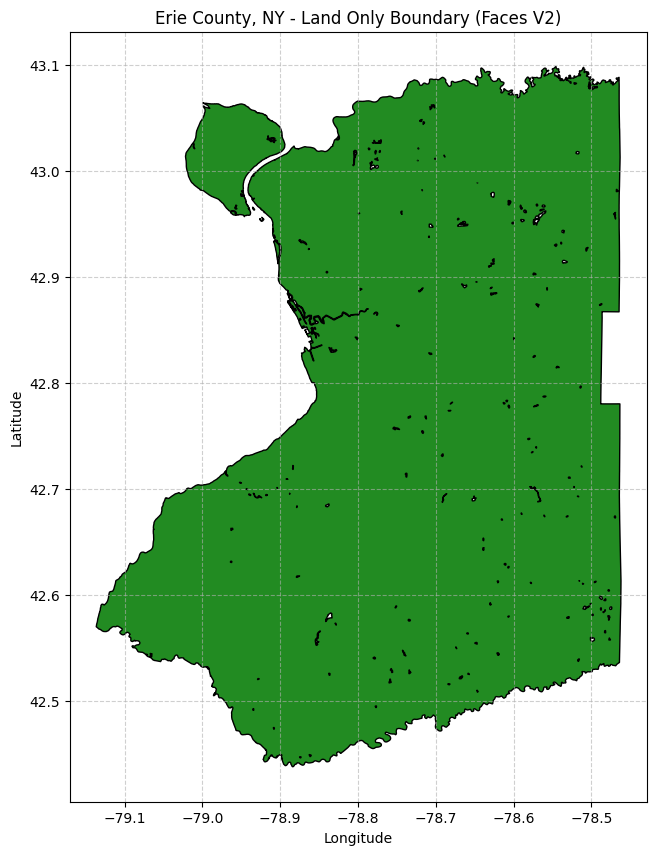

,id,TFID,STATEFP20,COUNTYFP20,TRACTCE20,BLKGRPCE20,BLOCKCE20,SUFFIX1CE,ZCTA5CE20,UACE20,...,SLDLST,CSAFP,CBSAFP,METDIVFP,LWFLAG,OFFSET,ATOTAL,INTPTLAT,INTPTLON,geometry
0,0,268539774,36,121,970300,3,3012,A,14004,11350,...,144,160,15380,None,L,N,10271,+42.8675775,-78.4833877,"MULTIPOLYGON (((-79.02742 42.54084, -79.02758 ..."


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

try:
    # Load the land-only GeoJSON
    gdf = gpd.read_file('erie_county_land_faces_v2.json')

    # Plot the geometry
    fig, ax = plt.subplots(figsize=(10, 10))
    gdf.plot(ax=ax, color='forestgreen', edgecolor='black')
    plt.title("Erie County, NY - Land Only Boundary (Faces V2)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # Display the first few rows of attribute data
    display(gdf.head())
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

In [ ]:
import geopandas as gpd
import json
from google.colab import files
from shapely.geometry import shape

# 1. Load census data
url = "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"
counties = gpd.read_file(url)

# 2. Extract Rensselaer
rensselaer = counties[(counties['STATEFP'] == '36') & (counties['NAME'] == 'Rensselaer')].copy()

# 3. Extract Monroe and Clip Water
# We filter for Monroe
monroe = counties[(counties['STATEFP'] == '36') & (counties['NAME'] == 'Monroe')].copy()

# To 'remove' the lake portion, we can use the 'STATE' boundary features which usually
# represent land area more closely, or we can filter by the 'AWATER' attribute if we had
# secondary shapefiles. However, the most effective way with TIGER files is to clip
# the county by the internal land-defined state boundary.
state_url = "https://www2.census.gov/geo/tiger/TIGER2023/STATE/tl_2023_us_state.zip"
states = gpd.read_file(state_url)
ny_land = states[states['STATEFP'] == '36']

# Clip Monroe to the NY State land boundary
monroe_clipped = gpd.clip(monroe, ny_land)

def save_and_download_geojson(gdf, filename):
    # Convert to dict and remove CRS
    geojson_dict = json.loads(gdf.to_json())
    if 'crs' in geojson_dict:
        del geojson_dict['crs']

    with open(filename, 'w') as f:
        json.dump(geojson_dict, f)
    print(f"Saved: {filename}")
    files.download(filename)

# Execute saves
save_and_download_geojson(rensselaer, 'rensselaer_county.json')
save_and_download_geojson(monroe_clipped, 'monroe_county_clipped.json')

Saved: rensselaer_county.json


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: monroe_county_clipped.json


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import geopandas as gpd

# Load the shapefile we just created
schenectady = gpd.read_file('schenectady_county/schenectady_county.shp')

# 1. Convert to GeoJSON
schenectady.to_file("schenectady_county.json", driver='GeoJSON')
print("Saved: schenectady_county.json")

# 2. Convert to CSV (Geometry will be in WKT format)
schenectady.to_csv("schenectady_county.csv", index=False)
print("Saved: schenectady_county.csv")

Saved: schenectady_county.json
Saved: schenectady_county.csv


In [ ]:
# 3. Convert to KML
# KML requires enabling the KML driver in fiona
import fiona
fiona.drvsupport.supported_drivers['KML'] = 'rw'

schenectady.to_file("schenectady_county.kml", driver='KML')
print("Saved: schenectady_county.kml")

Saved: schenectady_county.kml


In [ ]:
!pip install arcgis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.3/315.3 kB 27.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: dask
    Found existing installation: dask 2026.1.2
    Uninstalling dask-2026.1.2:
      Successfully uninstalled dask-2026.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the follo